# A SQL tour for quants

h5i-db's query layer is Apache DataFusion (full SQL with joins, CTEs and
window functions) extended with finance-native operators (`time_bucket`,
`rolling_avg`, `ewma`, `vwap`, ASOF joins) that exploit time-sorted
storage. This recipe is a guided tour: each stop is one concept applied to
a realistic task on a 50-name daily panel, ending with the resource guards
(`timeout=`, `max_rows=`) that keep exploratory SQL from taking down a
shared box. If you know kdb/q or pandas, this is your phrasebook.

In [1]:
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("00_sql_tour"), create=True)

prices = cu.make_daily_prices(days=500)  # 50 symbols x 500 sessions
db.create_table("prices", prices.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("prices", prices)

trades = cu.make_trades(days=1, trades_per_day=10_000)
db.create_table("trades", trades.schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades", trades)

print(f"prices: {len(prices):,} rows   trades: {len(trades):,} rows")

prices: 25,000 rows   trades: 26,476 rows


A static reference table for later joins. `time_column` is optional:
reference data (sector maps, symbol masters) doesn't need one, though it
then gets none of the time-based machinery (pruning, ASOF, `time_bucket`).

In [2]:
SECTORS = ["Tech", "Financials", "Energy", "Health Care", "Industrials"]
syms = sorted(set(prices["symbol"].to_pylist()))
db.create_table(
    "sectors",
    pa.schema([pa.field("symbol", pa.string()), pa.field("sector", pa.string())]),
)
db.append("sectors", pa.table({
    "symbol": pa.array(syms),
    "sector": pa.array([SECTORS[i % len(SECTORS)] for i in range(len(syms))]),
}))
db.sql("SELECT sector, count(*) AS names FROM sectors GROUP BY sector ORDER BY sector").to_pandas()

,sector,names
0,Energy,10
1,Financials,10
2,Health Care,10
3,Industrials,10
4,Tech,10


## 1. Time-range scans: let the manifest do the work

Segments are stored sorted by `ts` and the manifest records each segment's
time range, so a time predicate skips segments wholesale before any I/O.
Habit to build: **every** exploratory query on a big table starts with a
time filter. It is the difference between touching a week and touching
ten years. RFC3339 string literals compare directly against timestamp
columns.

In [3]:
db.sql(
    """
    SELECT count(*) AS rows, min(ts) AS first_session, max(ts) AS last_session
    FROM prices
    WHERE ts >= '2024-01-01T00:00:00Z' AND ts < '2024-04-01T00:00:00Z'
    """
).to_pandas()

,rows,first_session,last_session
0,3250,2024-01-01 20:00:00+00:00,2024-03-29 20:00:00+00:00


## 2. Aggregate + GROUP BY: the cross-sectional summary

In [4]:
db.sql(
    """
    SELECT symbol,
           count(*)                              AS sessions,
           round(avg(close), 2)                  AS avg_close,
           round(sum(close * volume) / 1e9, 2)   AS dollar_vol_bn
    FROM prices
    GROUP BY symbol
    ORDER BY dollar_vol_bn DESC
    LIMIT 10
    """
).to_pandas()

,symbol,sessions,avg_close,dollar_vol_bn
0,STK045,500,397.94,101.36
1,STK015,500,364.89,91.68
2,STK044,500,343.97,85.90
3,STK024,500,339.53,82.98
4,STK025,500,318.05,79.36
5,STK006,500,308.40,78.67
6,STK037,500,290.58,76.02
7,STK002,500,281.58,74.01
8,STK043,500,291.86,72.59
9,STK042,500,267.50,69.20


## 3. Window functions: returns, ranks, rolling risk

The three window patterns that cover 90% of daily-panel work:

- `lag()` for returns, with no self-join and no pandas round-trip;
- `row_number()` for "latest N per symbol" (partition, order DESC, filter);
- an explicit `ROWS BETWEEN` frame for rolling moments, here a trailing
  20-day annualized volatility.

In [5]:
db.sql(
    """
    SELECT ts, symbol, close,
           round(close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1, 5) AS ret_1d
    FROM prices
    WHERE symbol IN ('STK000', 'STK001')
    ORDER BY symbol, ts
    LIMIT 5
    """
).to_pandas()

,ts,symbol,close,ret_1d
0,2023-01-02 20:00:00+00:00,STK000,25.86,NaN
1,2023-01-03 20:00:00+00:00,STK000,26.26,0.01547
2,2023-01-04 20:00:00+00:00,STK000,26.27,0.00038
3,2023-01-05 20:00:00+00:00,STK000,27.23,0.03654
4,2023-01-06 20:00:00+00:00,STK000,27.26,0.00110


In [6]:
db.sql(
    """
    SELECT ts, symbol, close, rn
    FROM (
        SELECT ts, symbol, close,
               row_number() OVER (PARTITION BY symbol ORDER BY ts DESC) AS rn
        FROM prices
    )
    WHERE rn <= 3 AND symbol IN ('STK000', 'STK001')
    ORDER BY symbol, rn
    """
).to_pandas()

,ts,symbol,close,rn
0,2024-11-29 20:00:00+00:00,STK000,69.37,1
1,2024-11-28 20:00:00+00:00,STK000,67.99,2
2,2024-11-27 20:00:00+00:00,STK000,68.67,3
3,2024-11-29 20:00:00+00:00,STK001,183.61,1
4,2024-11-28 20:00:00+00:00,STK001,186.51,2
5,2024-11-27 20:00:00+00:00,STK001,189.25,3


In [7]:
db.sql(
    """
    WITH rets AS (
        SELECT ts, symbol,
               close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS r
        FROM prices
    )
    SELECT ts, symbol,
           round(stddev(r) OVER (
               PARTITION BY symbol ORDER BY ts
               ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
           ) * sqrt(252) * 100, 2) AS vol20_ann_pct
    FROM rets
    WHERE symbol = 'STK000'
    ORDER BY ts DESC
    LIMIT 5
    """
).to_pandas()

,ts,symbol,vol20_ann_pct
0,2024-11-29 20:00:00+00:00,STK000,21.17
1,2024-11-28 20:00:00+00:00,STK000,21.66
2,2024-11-27 20:00:00+00:00,STK000,22.12
3,2024-11-26 20:00:00+00:00,STK000,23.18
4,2024-11-25 20:00:00+00:00,STK000,23.93


## 4. h5i sugar: `rolling_avg` and `ewma`

`rolling_avg(x, ts, n)` (also `rolling_sum/min/max`) is shorthand for a
trailing n-row mean in `ts` order. **One sharp edge:** it runs over the
result rows in global time order and is *not* partitioned by symbol, so on
a multi-symbol table it will happily average AAPL into MSFT. Filter to one
symbol first (as below), or use the explicit
`avg(...) OVER (PARTITION BY symbol ...)` form for panels.

`ewma(x, alpha)` is a proper window function and *does* respect
`PARTITION BY`, giving RiskMetrics-style smoothing in one line.

In [8]:
ma = db.sql(
    """
    SELECT ts, close,
           rolling_avg(close, ts, 20)                       AS ma20_sugar,
           avg(close) OVER (ORDER BY ts
               ROWS BETWEEN 19 PRECEDING AND CURRENT ROW)   AS ma20_standard,
           ewma(close, 0.06) OVER (ORDER BY ts)             AS ewma_px
    FROM prices
    WHERE symbol = 'STK007'
    ORDER BY ts
    """
).to_pandas()

import numpy as np

assert np.allclose(ma["ma20_sugar"], ma["ma20_standard"])
print("rolling_avg == explicit OVER frame, verified on", len(ma), "rows")
ma.tail(3)

rolling_avg == explicit OVER frame, verified on 500 rows


,ts,close,ma20_sugar,ma20_standard,ewma_px
497,2024-11-27 20:00:00+00:00,223.06,220.4675,220.4675,212.686061
498,2024-11-28 20:00:00+00:00,217.90,220.9545,220.9545,212.998898
499,2024-11-29 20:00:00+00:00,220.91,221.6715,221.6715,213.473564


## 5. CTEs and joins: a returns → volatility → sector pipeline

CTEs keep multi-step research SQL readable: each stage is a named,
testable intermediate, and the whole pipeline runs as one plan (no
materialized temporaries). Here: daily returns → trailing 20d vol →
join the sector map → the current risk picture by sector.

In [9]:
sector_vol = db.sql(
    """
    WITH rets AS (
        SELECT ts, symbol,
               close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS r
        FROM prices
    ),
    vol AS (
        SELECT ts, symbol,
               stddev(r) OVER (PARTITION BY symbol ORDER BY ts
                               ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) * sqrt(252) AS v
        FROM rets
    ),
    latest AS (
        SELECT symbol, v
        FROM (SELECT symbol, v, row_number() OVER (PARTITION BY symbol ORDER BY ts DESC) rn FROM vol)
        WHERE rn = 1
    )
    SELECT s.sector,
           count(*)                    AS names,
           round(avg(l.v) * 100, 2)    AS avg_vol20_pct,
           round(max(l.v) * 100, 2)    AS max_vol20_pct
    FROM latest l
    JOIN sectors s USING (symbol)
    GROUP BY s.sector
    ORDER BY avg_vol20_pct DESC
    """
).to_pandas()
sector_vol

,sector,names,avg_vol20_pct,max_vol20_pct
0,Financials,10,28.04,38.39
1,Energy,10,26.00,35.75
2,Health Care,10,25.43,36.29
3,Tech,10,25.34,35.41
4,Industrials,10,24.79,37.45


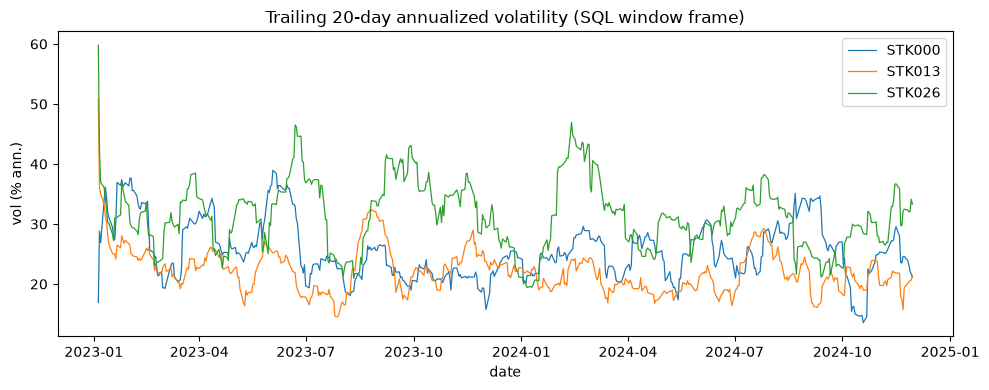

In [10]:
import matplotlib.pyplot as plt

vol_series = db.sql(
    """
    WITH rets AS (
        SELECT ts, symbol,
               close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS r
        FROM prices
        WHERE symbol IN ('STK000', 'STK013', 'STK026')
    )
    SELECT ts, symbol,
           stddev(r) OVER (PARTITION BY symbol ORDER BY ts
                           ROWS BETWEEN 19 PRECEDING AND CURRENT ROW) * sqrt(252) * 100 AS vol
    FROM rets ORDER BY ts
    """
).to_pandas()

fig, ax = plt.subplots(figsize=(10, 4))
for sym, g in vol_series.groupby("symbol"):
    ax.plot(g["ts"], g["vol"], lw=0.9, label=sym)
ax.set_title("Trailing 20-day annualized volatility (SQL window frame)")
ax.set_xlabel("date")
ax.set_ylabel("vol (% ann.)")
ax.legend()
fig.tight_layout()

## 6. Date machinery: `time_bucket`, `date_trunc`, `EXTRACT`

`time_bucket` is the workhorse: here monthly closes via
`last_value(... ORDER BY ts)` inside the GROUP BY (the idiom for "closing"
values; no self-join needed), chained into monthly returns with `lag`.
`date_trunc` does the same truncation without the extra widths/timezone
options; `EXTRACT` pulls calendar fields for seasonality cuts.

In [11]:
db.sql(
    """
    WITH monthly AS (
        SELECT time_bucket('1mo', ts) AS month, symbol,
               last_value(close ORDER BY ts) AS close_m
        FROM prices GROUP BY month, symbol
    )
    SELECT month, symbol,
           round(close_m / lag(close_m) OVER (PARTITION BY symbol ORDER BY month) - 1, 4) AS ret_1mo
    FROM monthly
    WHERE symbol = 'STK000'
    ORDER BY month DESC
    LIMIT 6
    """
).to_pandas()

,month,symbol,ret_1mo
0,2024-11-01 00:00:00+00:00,STK000,0.1092
1,2024-10-01 00:00:00+00:00,STK000,-0.0134
2,2024-09-01 00:00:00+00:00,STK000,-0.0231
3,2024-08-01 00:00:00+00:00,STK000,0.1285
4,2024-07-01 00:00:00+00:00,STK000,0.0327
5,2024-06-01 00:00:00+00:00,STK000,0.1116


In [12]:
# Day-of-week effect scan (EXTRACT dow: 0 = Sunday). A daily panel only has
# Mon-Fri; means this close to zero are exactly what an honest scan shows.
db.sql(
    """
    WITH rets AS (
        SELECT ts, close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS r
        FROM prices
    )
    SELECT EXTRACT(dow FROM ts) AS dow,
           count(*) AS obs,
           round(avg(r) * 1e4, 2) AS mean_ret_bps
    FROM rets GROUP BY dow ORDER BY dow
    """
).to_pandas()

,dow,obs,mean_ret_bps
0,1,5000,10.89
1,2,5000,2.71
2,3,5000,2.85
3,4,5000,5.69
4,5,5000,11.10


In [13]:
# Intraday cut on the tick table: hourly volume shows the session U-shape.
db.sql(
    """
    SELECT EXTRACT(hour FROM ts) AS hour_utc,
           count(*)              AS trades,
           sum(size)             AS shares
    FROM trades GROUP BY hour_utc ORDER BY hour_utc
    """
).to_pandas()

,hour_utc,trades,shares
0,13,6012,428471
1,14,6564,476636
2,15,2139,162744
3,16,1623,117920
4,17,1598,115805
5,18,2306,173289
6,19,6234,442001


## 7. Distributions and dependence: `approx_percentile_cont`, `corr`

Return quantiles without pulling half a million rows into pandas, and
pairwise correlation as a plain aggregate over a self-joined returns CTE.

In [14]:
db.sql(
    """
    WITH rets AS (
        SELECT close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS r
        FROM prices
    )
    SELECT round(approx_percentile_cont(r, 0.01) * 100, 3) AS p01_pct,
           round(approx_percentile_cont(r, 0.05) * 100, 3) AS p05_pct,
           round(approx_percentile_cont(r, 0.50) * 100, 3) AS p50_pct,
           round(approx_percentile_cont(r, 0.95) * 100, 3) AS p95_pct,
           round(approx_percentile_cont(r, 0.99) * 100, 3) AS p99_pct
    FROM rets
    """
).to_pandas()

,p01_pct,p05_pct,p50_pct,p95_pct,p99_pct
0,-4.101,-2.854,0.061,2.919,4.318


In [15]:
db.sql(
    """
    WITH rets AS (
        SELECT ts, symbol,
               close / lag(close) OVER (PARTITION BY symbol ORDER BY ts) - 1 AS r
        FROM prices
    )
    SELECT a.symbol AS sym_a, b.symbol AS sym_b,
           round(corr(a.r, b.r), 3) AS rho
    FROM rets a
    JOIN rets b USING (ts)
    WHERE (a.symbol, b.symbol) IN (('STK000','STK001'), ('STK000','STK025'), ('STK010','STK040'))
    GROUP BY a.symbol, b.symbol
    ORDER BY rho DESC
    """
).to_pandas()

,sym_a,sym_b,rho
0,STK000,STK025,0.466
1,STK000,STK001,0.239
2,STK010,STK040,0.178


## 8. Resource guards: fail fast, not slow

On a shared research box, the accidentally huge query does more damage than
the merely wrong one. Every `db.sql` call takes `timeout=` (seconds) and
`max_rows=`; blowing either raises a typed error (`TimeoutError`,
`LimitError`) with a `.code` your tooling can branch on. Set conservative
defaults in shared notebooks and raise them deliberately.

In [16]:
try:
    db.sql("SELECT * FROM prices", max_rows=1_000)  # 25,000-row table
except h5i_db.LimitError as e:
    print(f"LimitError  code={e.code}")
    print(f"message     {e}")

LimitError  code=limit_exceeded
message     [limit_exceeded] Resources exhausted: result exceeded max_rows = 1000; add a LIMIT or raise max_rows


In [17]:
try:
    # 25k x 25k row cross join: a typo away from a real query. The deadline
    # cancels it instead of letting it own the box.
    db.sql(
        "SELECT a.symbol, corr(a.close, b.close) FROM prices a CROSS JOIN prices b GROUP BY a.symbol",
        timeout=1,
    )
except h5i_db.TimeoutError as e:
    print(f"TimeoutError  code={e.code}")
    print(f"hint          {e.hint}")

TimeoutError  code=timeout
hint          raise the timeout or narrow the query


## Takeaways

- Start every query with a time predicate: sorted segments + manifest time
  ranges mean the filter prunes I/O, not just rows.
- `lag` / `row_number` / `ROWS BETWEEN` frames cover returns, latest-N and
  rolling risk without leaving SQL; `last_value(x ORDER BY ts)` in a
  GROUP BY is the closing-value idiom.
- `rolling_avg` sugar is trailing-N-rows in global time order, so filter to
  one symbol first; `ewma` is a real window function and honors
  `PARTITION BY`.
- CTE pipelines (returns → vol → sector join) run as one plan; static
  reference tables can skip `time_column` entirely.
- `timeout=` and `max_rows=` turn runaway queries into typed, catchable
  errors, which is production etiquette for shared databases.

In [18]:
db.close()